In [1]:
from google.colab import files

uploaded = files.upload()

Saving bank.csv to bank.csv


In [2]:
import os
print(os.listdir())

['.config', 'bank.csv', 'sample_data']


In [3]:
import pandas as pd

df = pd.read_csv("bank.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Q6 Data Understanding

In [5]:
df.shape

(11162, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Interpretation
The dataset contains both numerical and categorical variables. Numerical variables include age, balance, duration, campaign, pdays, and previous. Categorical variables include job, marital status, education, default, housing, loan, contact, month, poutcome, and deposit. The target variable is deposit, which has two classes: "yes" and "no". Since Decision Tree models require numerical input, categorical variables will be converted into numerical values during the preprocessing stage.

Q7. Data Cleaning

In [8]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)

Missing Values
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Duplicate Rows: 0

Shape after removing duplicates: (11162, 17)


Interpretation

Checked missing values.
Removed duplicate records.
Dataset is now clean.

Q8. Data Preprocessing

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


Interpretation

Used Label Encoding.
Decision Tree accepts numerical values only.

Q9. Feature Selection & Train Test Split

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop("deposit", axis=1)

y = df["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8929, 16)
(2233, 16)


Interpretation

80% Training
20% Testing
Helps evaluate model on unseen data.

Q10 Decision Tree Model

In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

Interpretation

Used Gini Index.
max_depth=5 prevents excessive tree growth.

Q11 Model Evaluation

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy")
print(accuracy_score(y_test, prediction))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, prediction))

print("\nClassification Report")
print(classification_report(y_test, prediction))

Accuracy
0.8051948051948052

Confusion Matrix
[[867 299]
 [136 931]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



Interpretation

Accuracy shows overall prediction performance.
Precision measures correctness of positive predictions.
Recall measures ability to identify actual positives.

Q12 Overfitting Check

In [13]:
train_prediction = model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_prediction)

test_accuracy = accuracy_score(y_test, prediction)

print("Training Accuracy:", train_accuracy)

print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8149848807257252
Testing Accuracy: 0.8051948051948052


Interpretation

Training Accuracy >> Testing Accuracy → Over
Bboth are close → Good model.

Q13 Pruning

In [14]:
pruned_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

pruned_model.fit(X_train, y_train)

prediction2 = pruned_model.predict(X_test)

print("Accuracy")

print(accuracy_score(y_test, prediction2))

Accuracy
0.7653381101656964


Interpretation

Smaller tree.
Less overfitting.
Better generalization.

Q14 Feature Importance

     Feature  Importance
11  duration    0.595239
8    contact    0.121729
13     pdays    0.084299
6    housing    0.067469
10     month    0.054023


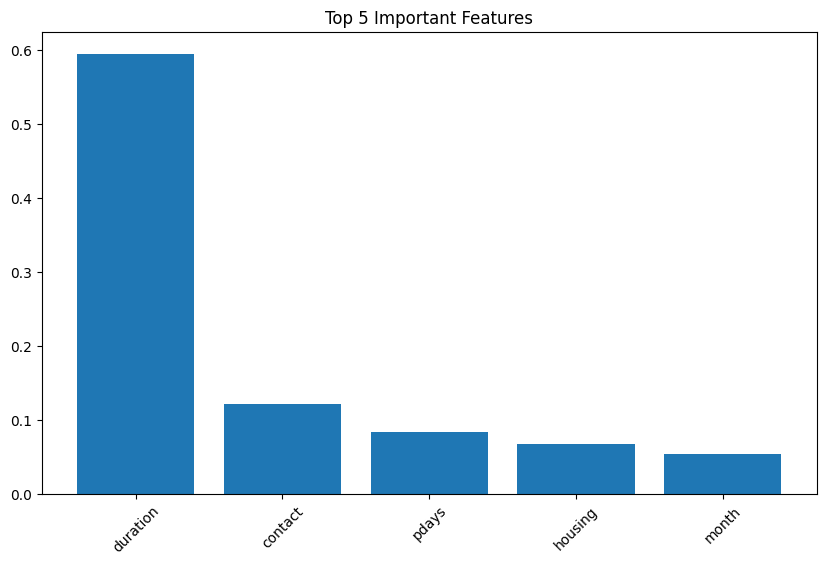

In [15]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head())

plt.figure(figsize=(10,6))
plt.bar(
    importance["Feature"][:5],
    importance["Importance"][:5]
)
plt.xticks(rotation=45)
plt.title("Top 5 Important Features")
plt.show()

Interpretation

Higher importance means greater influence on prediction.
Top features contribute the most to the Decision Tree's decisions.

Q15 Business Insights

Customers having higher account balances, longer call durations, successful previous campaign outcomes, and no previous loan defaults are generally more likely to subscribe to a term deposit. The bank should focus its marketing campaigns on customers with these characteristics. Personalized offers, targeted telemarketing, and follow-up calls to interested customers can significantly improve the success rate of future campaigns. Using Decision Tree predictions allows the bank to identify high-potential customers, reduce marketing costs, and improve campaign efficiency.